# Post-hoc tuning the cut-off point of decision function

Once a binary classifier is trained, the [predict](https://scikit-learn.org/stable/glossary.html#term-predict) method outputs class label predictions corresponding to a thresholding of either the [decision_function](https://scikit-learn.org/stable/glossary.html#term-decision_function) or the [predict_proba](https://scikit-learn.org/stable/glossary.html#term-predict_proba) output. The default threshold is defined as a posterior probability estimate of 0.5 or a decision score of 0.0. However, this default strategy may not be optimal for the task at hand.

This example shows how to use the [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html#sklearn.model_selection.TunedThresholdClassifierCV "sklearn.model_selection.TunedThresholdClassifierCV") to tune the decision threshold, depending on a metric of interest.

## The diabetes dataset

To illustrate the tuning of the decision threshold, we will use the diabetes dataset. This dataset is available on OpenML: [https://www.openml.org/d/37](https://www.openml.org/d/37). We use the [`fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html#sklearn.datasets.fetch_openml "sklearn.datasets.fetch_openml") function to fetch this dataset.

In [1]:
from sklearn.datasets import fetch_openml

diabetes = fetch_openml(data_id=37, as_frame=True, parser="pandas")
data, target = diabetes.data, diabetes.target

We look at the target to understand the type of problem we are dealing with.

In [2]:
target.value_counts()

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

We can see that we are dealing with a binary classification problem. Since the labels are not encoded as 0 and 1, we make it explicit that we consider the class labeled “tested_negative” as the negative class (which is also the most frequent) and the class labeled “tested_positive” the positive as the positive class:

In [3]:
neg_label, pos_label = target.value_counts().index

We can also observe that this binary problem is slightly imbalanced where we have around twice more samples from the negative class than from the positive class. When it comes to evaluation, we should consider this aspect to interpret the results.



## Our vanilla classifier

We define a basic predictive model composed of a scaler followed by a logistic regression classifier.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression()),
    ]
)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

- We evaluate our model using cross-validation. We use the accuracy and the balanced accuracy to report the performance of our model.
- The **balanced accuracy** is a metric that is less sensitive to class imbalance and will allow us to put the accuracy score in perspective.

**Cross-validation** allows us to study the variance of the decision threshold across different splits of the data. However, the dataset is rather small and it would be detrimental to use more than 5 folds to evaluate the dispersion. Therefore, we use a [`RepeatedStratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html#sklearn.model_selection.RepeatedStratifiedKFold "sklearn.model_selection.RepeatedStratifiedKFold") where we apply several repetitions of 5-fold cross-validation.

In [5]:
import pandas as pd

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

scoring = ["accuracy", "balanced_accuracy"]
cv_scores = [
    "train_accuracy",
    "test_accuracy",
    "train_balanced_accuracy",
    "test_balanced_accuracy",
]

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

cv_results_vanilla_model = pd.DataFrame(
    cross_validate(
        model,
        data,
        target,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
    )
)

cv_results_vanilla_model[cv_scores].aggregate(["mean", "std"]).T

,mean,std
train_accuracy,0.779751,0.007822
test_accuracy,0.770926,0.030585
train_balanced_accuracy,0.732913,0.009788
test_balanced_accuracy,0.723665,0.035914


- Our predictive model succeeds to grasp the relationship between the data and the target.
- The training and testing scores are close to each other, meaning that our predictive model is not overfitting.
- We can also observe that the **balanced accuracy is lower** than the accuracy, due to the class imbalance previously mentioned.

For this classifier, we let the decision threshold, used convert the probability of the positive class into a class prediction, to its default value: 0.5. **However**, this threshold might not be optimal. If our interest is to maximize the balanced accuracy, we should select another threshold that would maximize this metric.

The [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html#sklearn.model_selection.TunedThresholdClassifierCV "sklearn.model_selection.TunedThresholdClassifierCV") **meta-estimator** allows to: **tune the decision threshold of a classifier given a metric of interest**.

## Tuning the decision threshold

We create a [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html#sklearn.model_selection.TunedThresholdClassifierCV "sklearn.model_selection.TunedThresholdClassifierCV") and configure it to maximize the balanced accuracy. We evaluate the model using the same cross-validation strategy as previously.

In [6]:
from sklearn.model_selection import TunedThresholdClassifierCV

tuned_model = TunedThresholdClassifierCV(
    estimator=model,
    scoring="balanced_accuracy"
)

cv_results_tuned_model = pd.DataFrame(
    cross_validate(
        tuned_model,
        data,
        target,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
    )
)

cv_results_tuned_model[cv_scores].aggregate(["mean", "std"]).T

,mean,std
train_accuracy,0.752470,0.015579
test_accuracy,0.739950,0.036592
train_balanced_accuracy,0.757915,0.009747
test_balanced_accuracy,0.744029,0.035445


In comparison with the vanilla model, we observe that the balanced accuracy score increased. Of course, it comes at the cost of a lower accuracy score. It means that our model is now more sensitive to the positive class but makes more mistakes on the negative class.

However, it is important to note that this tuned predictive model is internally the same model as the vanilla model: **they have the same fitted coefficients**.



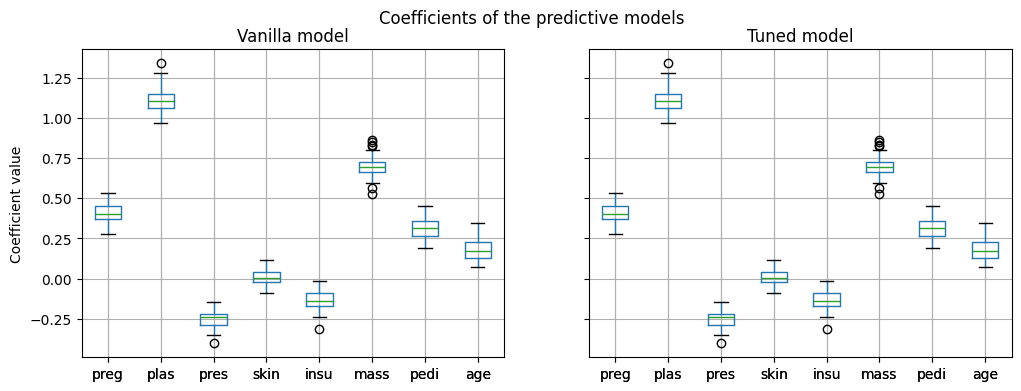

In [7]:
import matplotlib.pyplot as plt

vanilla_model_coef = pd.DataFrame(
    [est[-1].coef_.ravel() for est in cv_results_vanilla_model["estimator"]],
    columns=diabetes.feature_names,
)
tuned_model_coef = pd.DataFrame(
    [est.estimator_[-1].coef_.ravel() for est in cv_results_tuned_model["estimator"]],
    columns=diabetes.feature_names,
)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharex=True, sharey=True)
vanilla_model_coef.boxplot(ax=ax[0])
ax[0].set_ylabel("Coefficient value")
ax[0].set_title("Vanilla model")
tuned_model_coef.boxplot(ax=ax[1])
ax[1].set_title("Tuned model")
_ = fig.suptitle("Coefficients of the predictive models")

**Only the decision threshold of each model was changed** during the cross-validation.



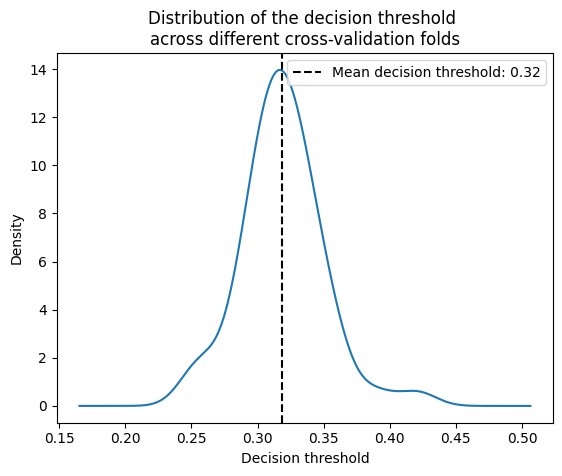

In [8]:
decision_threshold = pd.Series(
    [
        est.best_threshold_
        for est in cv_results_tuned_model["estimator"]
    ],
)
ax = decision_threshold.plot.kde()
ax.axvline(
    decision_threshold.mean(),
    color="k",
    linestyle="--",
    label=f"Mean decision threshold: {decision_threshold.mean():.2f}",
)
ax.set_xlabel("Decision threshold")
ax.legend(loc="upper right")
_ = ax.set_title(
    "Distribution of the decision threshold \nacross different cross-validation folds"
)

In average, a decision threshold around 0.32 maximizes the balanced accuracy, which is different from the default decision threshold of 0.5. Thus tuning the decision threshold is particularly important when the output of the predictive model is used to make decisions.

The choice of the “right” metric is usually problem-dependent and might require some **domain knowledge**. We illustrate this next..

## Tune the model to specific domain metrics

- **Precision** is proportional to the threshold; the higher the threshold, the less False Positives (`FP`)
- **Recall** is inversely proportional to the threshold; the higher the threshold, the less False Negatives (`FN`)

In practice, we can weigh `FP` and `FN` by how much cost they incur on us. Then, choose the decision threshold that minimizes the net cost. Once we quantify how costly a `FP` and a `FN` is; we turn this into, yet another *Optimization problem*; i.e., **Cost Minimization**.

In business cost may be money.

The following example shows a clinical example where:

- The target distribution is imbalanced because most people are healthy.
- The cost of `FN` (not admitting a sick person) is estimated to be 5 times as much "costly" in comparison to `FP` (admitting a healthy person).

First, let's load and prepare the dataset:

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV

# data_id=37 corresponds to the Pima Indians Diabetes dataset
diabetes_data = fetch_openml(data_id=37, as_frame=True, parser="pandas")
X = diabetes_data.data
y_raw = diabetes_data.target

# The target contains 'tested_positive' and 'tested_negative'.
# We map 'tested_positive' to 1 (the class where False Negatives occur).
y = (y_raw == 'tested_positive').astype(int)

Split the data safely to prevent data leakage during threshold tuning:

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42,
)

Define the strict 5:1 cost function (FN penalty = 5, FP penalty = 1)

In [11]:
COST_FN = 5
COST_FP = 1

def domain_cost_function(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate exact business cost
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    # Return negative cost because scikit-learn optimizers maximize scores
    return -total_cost

cost_scorer = make_scorer(domain_cost_function)

Address Imbalance During Training. We use `class_weight='balanced'` so the model learns the structural patterns without predicting the majority class (negative) by default.

In [12]:
base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

Other ML algorithms with native `class_weight` support:

| **Algorithm Family**        | **Scikit-Learn Classes**                                                                              |
| --------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Linear Models**           | `LogisticRegression`, `RidgeClassifier`, `SGDClassifier`, `Perceptron`, `PassiveAggressiveClassifier` |
| **Support Vector Machines** | `SVC`, `LinearSVC`, `NuSVC`                                                                           |
| **Trees and Ensembles**     | `DecisionTreeClassifier`, `RandomForestClassifier`, `ExtraTreesClassifier`                            |

A perfectly calibrated model outputs a predicted probability that matches the empirical likelihood of the event. If a calibrated model predicts a 0.7 (70%) probability of diabetes for 100 patients, exactly 70 of those patients should actually have diabetes.

When you use `class_weight='balanced'` to counter an imbalanced dataset, you deliberately destroy the model's probability calibration. Calibration fits strictly **between** training the model and tuning the decision threshold.

Thus we need a `CalibratedClassifierCV`:

In [13]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrator: Maps the uncalibrated scores back to true probabilities.
# cv=5 means it trains 5 base models and 5 calibrators, creating an ensemble.
# method='isotonic' applies a non-parametric monotonic function to correct the curve.
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',
    cv=5
)

**Address Costs Post-Training**. We wrap the balanced model in the threshold tuner to minimize our specific cost matrix.

In [14]:
tuned_model = TunedThresholdClassifierCV(
    estimator=calibrated_model,
    scoring=cost_scorer,
    cv=3
)

Note: we have created a nested cross-validation where we'll have a $5 \times 3 = 15$ fits.

Let's fit the entire pipeline:

In [15]:
tuned_model.fit(X_train, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",CalibratedCla...od='isotonic')
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",make_scorer(d...hod='predict')
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",3
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Us

**Evaluate and Compare**. Notice we are using `y_test` only here, to just show the final result of the model. This won't influence another iteration on the model, as per our agreement of integrity and scientific honesty.

In [16]:
# Tuned: The balanced model using the optimized threshold
tuned_preds = tuned_model.predict(X_test)
tuned_cm = confusion_matrix(y_test, tuned_preds)
tuned_cost = (tuned_cm[0, 1] * COST_FP) + (tuned_cm[1, 0] * COST_FN)

# Also, let's fit the Baseline (using the default 0.5 threshold) for comparison:
base_model.fit(X_train, y_train)
base_preds = base_model.predict(X_test)
base_cm = confusion_matrix(y_test, base_preds)
base_cost = (base_cm[0, 1] * COST_FP) + (base_cm[1, 0] * COST_FN)

print(f"Optimal Decision Threshold Found: {tuned_model.best_threshold_:.4f}\n")
print("--- Default Threshold (0.50) ---")
print(f"False Positives: {base_cm[0, 1]}")
print(f"False Negatives: {base_cm[1, 0]}")
print(f"Total Cost: {base_cost}\n")
print(f"--- Tuned Threshold ({tuned_model.best_threshold_:.2f}) ---")
print(f"False Positives: {tuned_cm[0, 1]}")
print(f"False Negatives: {tuned_cm[1, 0]}")
print(f"Total Cost: {tuned_cost}")

Optimal Decision Threshold Found: 0.1163

--- Default Threshold (0.50) ---
False Positives: 32
False Negatives: 23
Total Cost: 147

--- Tuned Threshold (0.12) ---
False Positives: 80
False Negatives: 3
Total Cost: 95


## Key Takeaways

1. **Default thresholds are often suboptimal.** Binary classifiers use a default decision threshold (0.5 for `predict_proba`, 0.0 for `decision_function`). This may not match your metric or cost structure, so tuning the threshold after training can improve performance without retraining the model.

2. **Use `TunedThresholdClassifierCV` for post-hoc threshold tuning.** This meta-estimator finds the threshold that optimizes a chosen metric (e.g. `balanced_accuracy`) or a custom scorer. Only the cutoff is tuned; the underlying classifier's parameters stay fixed. Use cross-validation to estimate threshold variance and avoid overfitting.

3. **Choose the metric to optimize.** For imbalanced data, **balanced accuracy** is more informative than accuracy. For domain-specific trade-offs, define a **custom cost** (e.g. costs for false positives vs false negatives) and use `make_scorer` to minimize total cost; the "right" metric depends on the problem and domain knowledge.

4. **Threshold trades off precision and recall.** Higher threshold → fewer FPs (higher precision), more FNs (lower recall). You can frame the choice as minimizing a cost that weights FP and FN by their real-world impact.

5. **Calibration before threshold tuning.** If you use `class_weight='balanced'` (or similar) to handle imbalance, the model's probability calibration is affected. Apply **probability calibration** (e.g. `CalibratedClassifierCV`) after training and **before** tuning the decision threshold so that thresholds are meaningful.

6. **Pipeline order: train → calibrate (if needed) → tune threshold.** Split data properly (train/validation/test) and use the test set only for final evaluation to preserve scientific honesty and avoid leakage.